In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [133]:
def gbm_path(S0, r, sigma, T, n_steps):
    dt = T / n_steps
    Z = np.random.standard_normal(n_steps)
    S = np.zeros(n_steps)
    S[0] = S0
    for t in range(1, n_steps):
        S[t] = S[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t-1])
    
    df = pd.DataFrame({
        'day': np.arange(n_steps),
        'price': S
    })
    return df

In [134]:
def gbm_paths(S0, r, T, n_steps, n_paths):
    dfs = []
    for i in range(n_paths):
        sigma = np.random.uniform(0.01, 0.5)
        path = gbm_path(S0, r, sigma, T, n_steps)
        path['simulation'] = i
        dfs.append(path)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [135]:
def estimate_volatility(df, window=20, noise_std=0.02):
    for sim in tqdm(df["simulation"].unique(), desc = "Estimate Vol"):
        mask = df["simulation"]==sim
        prices = df.loc[mask, 'price']
        log_returns = np.log(prices / prices.shift(1))
        realized_vol = log_returns.rolling(window).std() * np.sqrt(252)
        df.loc[mask, 'sigma'] = realized_vol
    
   
    df['sigma'] = df['sigma'].fillna(method='bfill')
    return df


In [136]:
df1 = gbm_paths(8173, 0.03, 5, 5*252, 10000)


In [137]:
df1.head()

,day,price,simulation
0,0,8173.000000,0
1,1,8169.017012,0
2,2,8165.447324,0
3,3,8191.336522,0
4,4,8213.832666,0


In [138]:
full_df = estimate_volatility(df1, 20, 0.1)

Estimate Vol: 100%|██████████| 10000/10000 [04:47<00:00, 34.73it/s]
C:\Users\theia\AppData\Local\Temp\ipykernel_14756\1058190852.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['sigma'] = df['sigma'].fillna(method='bfill')


In [139]:
full_df.head()

,day,price,simulation,sigma
0,0,8173.000000,0,0.037076
1,1,8169.017012,0,0.037076
2,2,8165.447324,0,0.037076
3,3,8191.336522,0,0.037076
4,4,8213.832666,0,0.037076


In [140]:
print(full_df["sigma"].nunique())

12400000


In [154]:
full_df = full_df[full_df['day'] >= 20].reset_index(drop=True)

In [155]:
full_df.shape

(12400000, 4)

In [142]:
full_df.to_csv('gbm_stock_paths_vol.csv', index=False)

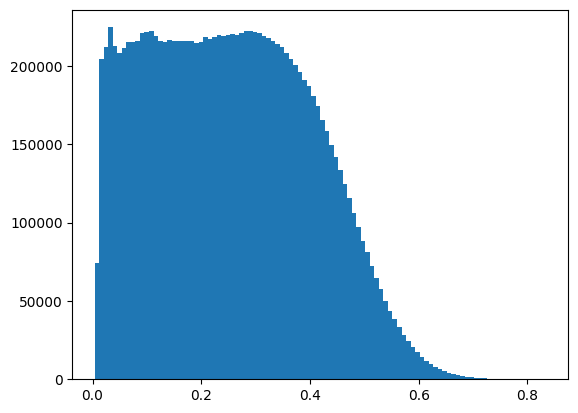

In [156]:
plt.hist(full_df["sigma"], bins = 100)
plt.show()

In [157]:
daily_change = full_df.groupby('simulation')['sigma'].pct_change() *100
print(f"Mean: {daily_change.mean():.6f}")

Mean: 0.153631


In [158]:
sigma_t = full_df.groupby('simulation')['sigma'].shift(1)
corr = full_df['sigma'].corr(sigma_t)
print(f"GBM — lag-1 correlation: {corr:.4f}")

GBM — lag-1 correlation: 0.9945


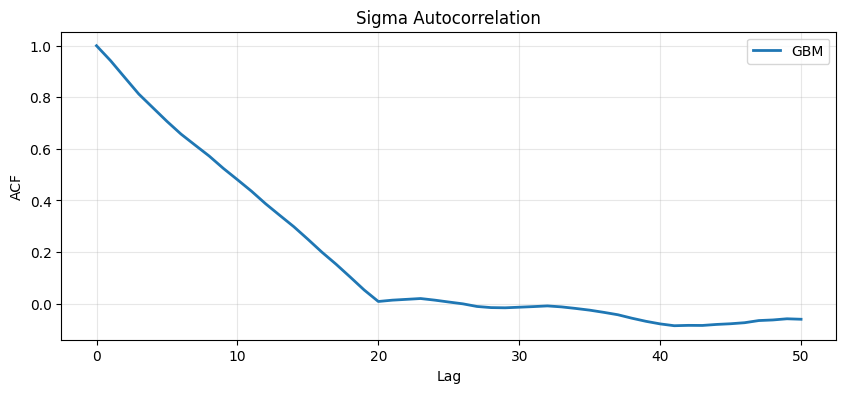

In [159]:
from statsmodels.tsa.stattools import acf

sim0_gbm = full_df[full_df['simulation'] == 0]['sigma'].dropna().values

plt.figure(figsize=(10, 4))
plt.plot(acf(sim0_gbm, nlags=50), label='GBM', linewidth=2)
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('Sigma Autocorrelation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()